<span style="color:#1d4ed8">→ <strong>Code update:</strong> Enabled the imports used throughout the TP.</span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print(f'NumPy {np.__version__}; pandas {pd.__version__}')

NumPy 2.0.2; pandas 2.3.3


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The version numbers identify the libraries used for this run.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Imported the current preprocessing and selection tools.</span>

In [2]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

print('Imports ready. All examples below run in the standard Kaggle Python environment.')

Imports ready. All examples below run in the standard Kaggle Python environment.


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The preprocessing and feature-selection classes are ready for later examples.</span>


## Method (1): Create a Dataframe from multiple series

We start by creating a Pandas series which is like a column in a table with index.

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Created the two planned student Series.</span>

In [3]:
# Create two Series with partly different student indexes.
age = pd.Series([23, 22, 25], index=['Student1', 'Student2', 'Student3'], name='age')
height = pd.Series([155, 175, 168], index=['Student1', 'Student3', 'Student4'], name='height')
display(age.to_frame(), height.to_frame())

,age
Student1,23
Student2,22
Student3,25


,height
Student1,155
Student3,175
Student4,168


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The two Series have different student labels, which makes their alignment visible in the next output.</span>

**A dataframe** can be composed of multiple series, or it can be defined as a collection of series that can be used to analyze data.

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Combined the Series into a DataFrame.</span>

In [4]:
stat = pd.DataFrame({'age': age, 'height': height})
display(stat)

,age,height
Student1,23.0,155.0
Student2,22.0,NaN
Student3,25.0,175.0
Student4,NaN,168.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Pandas aligns the Series by student label; students absent from a Series receive <code>NaN</code> in that column.</span>

## Method (2): Load a Dataframe



<span style="color:#1d4ed8">→ <strong>Code update:</strong> Loaded Horse Colic from your Kaggle path.</span>

In [5]:
# Method (2): load the attached Horse Colic CSV.
stat2 = pd.read_csv('/kaggle/input/datasets/uciml/horse-colic/horse.csv')
print('Horse-colic shape:', stat2.shape)
display(stat2.head())

Horse-colic shape: (299, 28)


,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,no,adult,530101,38.5,66.0,28.0,cool,reduced,NaN,more_3_sec,...,45.0,8.4,NaN,NaN,died,no,11300,0,0,no
1,yes,adult,534817,39.2,88.0,20.0,NaN,NaN,pale_cyanotic,less_3_sec,...,50.0,85.0,cloudy,2.0,euthanized,no,2208,0,0,no
2,no,adult,530334,38.3,40.0,24.0,normal,normal,pale_pink,less_3_sec,...,33.0,6.7,NaN,NaN,lived,no,0,0,0,yes
3,yes,young,5290409,39.1,164.0,84.0,cold,normal,dark_cyanotic,more_3_sec,...,48.0,7.2,serosanguious,5.3,died,yes,2208,0,0,yes
4,no,adult,530255,37.3,104.0,35.0,NaN,NaN,dark_cyanotic,more_3_sec,...,74.0,7.4,NaN,NaN,died,no,4300,0,0,no


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> This Kaggle file has 299 rows; missing entries are <code>NaN</code>.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Loaded the TP workbook from your Kaggle path.</span>

In [6]:
# Method (2): load the Excel file supplied with the TP.
stat3 = pd.read_excel(
    '/kaggle/input/datasets/aab6ss/data-xlsx/data.xlsx',
    index_col=0, na_values=['NaN', '?'],
)
stat3.index.name = 'student'
print('Excel data shape:', stat3.shape)
display(stat3)

Excel data shape: (4, 2)


,age,height
student,,
Etudiant1,23.0,155.0
Etudiant2,22.0,NaN
Etudiant3,25.0,175.0
Etudiant4,NaN,168.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The supplied workbook contains four students, with age and height in separate columns. The text <code>NaN</code> is treated as missing data.</span>

## Method(3): Create a Dataframe



<span style="color:#1d4ed8">→ <strong>Code update:</strong> Created the planned table with missing values.</span>

In [7]:
# Construct a small DataFrame with missing values for the cleaning examples.
df = pd.DataFrame({
    'Type': ['Student1', 'Student2', 'Student3', 'Student4'],
    'order': [2, 10, np.nan, 10],
    'age': [23, np.nan, 25, 0],
    'height': [155, 160, np.nan, 160],
})
display(df)

,Type,order,age,height
0,Student1,2.0,23.0,155.0
1,Student2,10.0,NaN,160.0
2,Student3,NaN,25.0,NaN
3,Student4,10.0,0.0,160.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Three numeric cells are intentionally missing so the following cleaning methods have observable effects.</span>

<p style="font-family: Arial; font-size:1.75em;color:red; font-style:bold"><br>
III.Get information about a dataset</p><br>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Loaded Titanic from your Kaggle path.</span>

In [8]:
# Inspect the attached Titanic training CSV.
data = pd.read_csv('/kaggle/input/datasets/hesh97/titanicdataset-traincsv/train.csv')
print('Titanic data loaded:', data.shape)

Titanic data loaded: (891, 12)


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The packaged Titanic training file contains 891 passenger rows and 12 columns. The <code>Survived</code> column is available for the later inspection steps.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Displayed a sample of the Titanic records.</span>

In [9]:
display(data.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The first rows show the target <code>Survived</code> alongside passenger details and visible missing entries.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Displayed the dataset shape.</span>

In [10]:
print('Rows, columns:', data.shape)

Rows, columns: (891, 12)


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Shape reports the number of passenger records and columns; it does not measure missingness.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Displayed the first records.</span>

In [11]:
display(data.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The head confirms the column names and a sample of the first records.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Displayed the last records.</span>

In [12]:
display(data.tail())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The tail checks the last records and helps catch truncated or misread files.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Ran the TP&#x27;s column summary.</span>

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Non-null counts reveal incomplete columns, while dtypes distinguish numeric and text fields.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Ran the TP&#x27;s numeric summary.</span>

In [14]:
display(data.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> These summaries cover numeric columns only; <code>count</code> is lower where a numeric column has missing values.</span>

<p style="font-family: Arial; font-size:1.75em;color:red; font-style:bold"><br>
IV Data Preparation </p><br>


<font color='blue' ><h3>
IV.1. Data Cleaning </p><h3>

## (1): Checking for NAN values

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Activated the missing-value check.</span>

In [15]:
print('Any missing values?', df.isnull().values.any())

Any missing values? True


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> <code>True</code> confirms that at least one cell in the example table is missing.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Displayed missing counts by column.</span>

In [16]:
display(df.isnull().sum().rename('missing_count').to_frame())

,missing_count
Type,0
order,1
age,1
height,1


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The per-column counts locate the missing values; the text <code>Type</code> column is complete.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Counted all missing cells.</span>

In [17]:
print('Total missing cells:', df.isnull().sum().sum())

Total missing cells: 3


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> This is the sum of the per-column missing counts.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Checked whether observed values exist.</span>

In [18]:
print('Any observed values?', df.notnull().values.any())

Any observed values? True


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> <code>True</code> means the table contains at least one observed value.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Counted all observed cells.</span>

In [19]:
print('Total observed cells:', df.notnull().sum().sum())

Total observed cells: 13


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Observed cells plus missing cells equal the table&#x27;s total number of cells.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Repeated the check with <code>isna()</code>.</span>

In [20]:
display(df.isna().sum().rename('missing_count').to_frame())

,missing_count
Type,0
order,1
age,1
height,1


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> <code>isna()</code> is an alias of <code>isnull()</code>, so these counts match the earlier output.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Counted missing cells with <code>isna()</code>.</span>

In [21]:
print('Total missing cells using isna:', df.isna().sum().sum())

Total missing cells using isna: 3


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The total matches the earlier <code>isnull()</code> calculation.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Counted observed cells with <code>notna()</code>.</span>

In [22]:
print('Total observed cells using notna:', df.notna().sum().sum())

Total observed cells using notna: 13


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The total matches the earlier <code>notnull()</code> calculation.</span>

## (2): Common Methods to Imputing Missing Data

There are different methods that we use to impute missing data such that: Mean strategy, Median technique and Mode technique.\

#### *) Mean strategy


<span style="color:#1d4ed8">→ <strong>Code update:</strong> Applied mean imputation to numeric columns.</span>

In [23]:
# Mean imputation affects only numeric columns; keep the source df unchanged.
df_mean = df.copy()
numeric = df_mean.select_dtypes(include='number').columns
df_mean[numeric] = df_mean[numeric].fillna(df_mean[numeric].mean())
display(df_mean)

,Type,order,age,height
0,Student1,2.000000,23.0,155.000000
1,Student2,10.000000,16.0,160.000000
2,Student3,7.333333,25.0,158.333333
3,Student4,10.000000,0.0,160.000000


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Each missing numeric value is replaced by its column mean; the original <code>df</code> stays available for comparison.</span>

#### *) Median technique


<span style="color:#1d4ed8">→ <strong>Code update:</strong> Applied median imputation to numeric columns.</span>

In [24]:
# Median is less affected by extreme observations than mean.
df_median = df.copy()
numeric = df_median.select_dtypes(include='number').columns
df_median[numeric] = df_median[numeric].fillna(df_median[numeric].median())
display(df_median)

,Type,order,age,height
0,Student1,2.0,23.0,155.0
1,Student2,10.0,23.0,160.0
2,Student3,10.0,25.0,160.0
3,Student4,10.0,0.0,160.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Median imputation uses the middle observed value in each numeric column and can resist outliers better than a mean.</span>

#### *) Mode technique (most frequent value)


<span style="color:#1d4ed8">→ <strong>Code update:</strong> Filled the missing height with its mode.</span>

In [25]:
# Mode imputation uses the most common observed height.
df_mode = df.copy()
df_mode['height'] = df_mode['height'].fillna(df_mode['height'].mode().iloc[0])
display(df_mode)

,Type,order,age,height
0,Student1,2.0,23.0,155.0
1,Student2,10.0,NaN,160.0
2,Student3,NaN,25.0,160.0
3,Student4,10.0,0.0,160.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The missing height becomes 160, the most frequent observed height.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Filled the missing order with its mode.</span>

In [26]:
# Apply the same approach to order; ties use pandas' first sorted mode.
df_mode['order'] = df_mode['order'].fillna(df_mode['order'].mode().iloc[0])
display(df_mode)

,Type,order,age,height
0,Student1,2.0,23.0,155.0
1,Student2,10.0,NaN,160.0
2,Student3,10.0,25.0,160.0
3,Student4,10.0,0.0,160.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The missing order becomes 10, its most frequent observed value.</span>

<font color='blue' ><h3>
IV.2. Feature selection </p><h3>

Feature selection is used to determine the best set of features for building useful models.

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Loaded Pima diabetes from your Kaggle path.</span>

In [27]:
# Load Pima diabetes and retain the TP's short feature names.
dataframe = pd.read_csv(
    '/kaggle/input/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/diabetes.csv'
)
dataframe.columns = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
names = dataframe.columns.tolist()
print('Pima shape:', dataframe.shape)
display(dataframe.head())

Pima shape: (768, 9)


,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> This 768-row file has filled measurements, so its feature ranking differs from the older raw data.</span>

After loading the dataframe, we convert it to a NumPy array to speed up the
calculation with separation the features and labels.

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Separated predictors from the class label.</span>

In [28]:
array = dataframe.to_numpy()
X1 = array[:, 0:8]
Y1 = array[:, 8].astype(int)
print('Feature matrix:', X1.shape, 'Target:', Y1.shape)

Feature matrix: (768, 8) Target: (768,)


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The feature matrix excludes the class column, which becomes the target vector.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Confirmed the feature-selection imports.</span>

In [29]:
print('SelectKBest and chi2 are available.')

SelectKBest and chi2 are available.


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The next cell fits the chi-squared filter to the nonnegative feature matrix.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Fitted the chi-squared feature filter.</span>

In [30]:
# Chi-squared requires nonnegative features; these columns satisfy that condition.
test = SelectKBest(score_func=chi2, k=4)
fit = test.fit(X1, Y1)
display(pd.Series(fit.scores_, index=names[:-1], name='chi2_score').sort_values(ascending=False).to_frame())

,chi2_score
test,6107.908339
plas,1439.168619
skin,181.546053
age,181.303689
preg,111.519691
mass,111.489994
pres,47.267258
pedi,5.392682


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Higher chi-squared scores indicate stronger univariate associations with the class; scores depend on each feature&#x27;s scale.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Displayed ranked scores and selected names.</span>

In [31]:
feature_scores = pd.Series(fit.scores_, index=names[:-1], name='chi2_score')
selected_features = feature_scores.index[fit.get_support()].tolist()
print('Four selected features:', selected_features)
display(feature_scores.sort_values(ascending=False).to_frame())

Four selected features: ['plas', 'skin', 'test', 'age']


,chi2_score
test,6107.908339
plas,1439.168619
skin,181.546053
age,181.303689
preg,111.519691
mass,111.489994
pres,47.267258
pedi,5.392682


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The four selected columns are the ones with the highest scores in this sample.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Displayed the four selected features.</span>

In [32]:
features = fit.transform(X1)
print('Selected matrix shape:', features.shape)
display(pd.DataFrame(features[:5], columns=selected_features))

Selected matrix shape: (768, 4)


,plas,skin,test,age
0,148.0,35.0,169.5,50.0
1,85.0,29.0,102.5,31.0
2,183.0,32.0,169.5,32.0
3,89.0,23.0,94.0,21.0
4,137.0,35.0,168.0,33.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The transformed table retains only the selected columns and keeps the original row order.</span>

### Interpretation:

You can now see the scores for each attribute and the 4 selected attributes (those with the highest scores)are: test, plas, age, mass.

These scores will further help you to determine the best features to train your model.

<span style="color:#b91c1c">→ <strong>Interpretation:</strong> This Kaggle file selects <code>plas</code>, <code>skin</code>, <code>test</code>, and <code>age</code>; the TP sentence above reflects older data.</span>

<font color='blue' ><h3>
IV.3. Data transformation </p><h3>

## A.Categorical features

Transforming categorical data is an essential step during data preprocessing. sklearn’s machine learning library require the input dataset to always have numeric values it does not support categorical data.

It is necessary to convert categorical features to a numerical representation.

Before you start transforming your data, it is important to figure out if the feature you’re working on is ordinal (as opposed to nominal). An ordinal feature is best described as a feature with  ordered categories.

Once you know what type of categorical data you’re working on, you can pick a suiting transformation tool. In sklearn that will be a OrdinalEncoder or LabelEncoder for ordinal data, and a OneHotEncoder for nominal data.

Let’s consider a simple example to demonstrate how both classes are working. Create a dataframe with four entries and three features: sex, blood type and education level.

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Introduced the TP&#x27;s categorical example.</span>

In [33]:
print('Categorical encoding example: four records and three features.')

Categorical encoding example: four records and three features.


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The example includes an ordered education feature and two unordered categorical features.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Created the planned categorical table.</span>

In [34]:
X1_cat = pd.DataFrame([
    ['M', 'O-', 'medium'], ['M', 'O-', 'high'],
    ['F', 'O+', 'high'], ['F', 'AB', 'low'],
], columns=['sex', 'blood_type', 'edu_level'])
display(X1_cat)

,sex,blood_type,edu_level
0,M,O-,medium
1,M,O-,high
2,F,O+,high
3,F,AB,low


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Education can be ranked low–medium–high; sex and blood type are nominal categories.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Displayed the table before encoding.</span>

In [35]:
display(X1_cat)

,sex,blood_type,edu_level
0,M,O-,medium
1,M,O-,high
2,F,O+,high
3,F,AB,low


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> This is the unchanged categorical input before encoding.</span>

### 1.Ordinal Feature
Looking at the dataframe, you should notice education level is the only ordinal feature (it can be ordered and the distance between the categories is not known). We’ll start with encoding this feature with the OrdinalEncoder class. Import the class and create a new instance. Then update the education level feature by fitting and transforming the feature to the encoder. The result should look as below.

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Encoded education in its intended order.</span>

In [36]:
# Set the intended education order explicitly.
encoder = OrdinalEncoder(categories=[['low', 'medium', 'high']])
X1_encoded = X1_cat.copy()
X1_encoded['edu_level'] = encoder.fit_transform(X1_cat[['edu_level']]).ravel()
display(X1_encoded)

,sex,blood_type,edu_level
0,M,O-,1.0
1,M,O-,2.0
2,F,O+,2.0
3,F,AB,0.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The ordered labels map to 0, 1, and 2, preserving their rank without claiming equal real-world distances.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Displayed the ordinal-encoded table.</span>

In [37]:
display(X1_encoded)

,sex,blood_type,edu_level
0,M,O-,1.0
1,M,O-,2.0
2,F,O+,2.0
3,F,AB,0.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Only <code>edu_level</code> changes; nominal columns remain text until one-hot encoding.</span>

Notice that we have a rather annoying issue here: our missing value is encoded as a separate class (3.0). Looking thoroughly at the documentation reveals that there is no solution for this issue yet. A good sign is that the sklearn developers are discussing the possibilities of implementing a suiting solution.
Another problem is that the order of our data is not respected. This can luckily be solved by passing an ordered list of unique values for the feature to the categories parameter.

<span style="color:#b91c1c">→ <strong>Interpretation:</strong> This four-row example has no missing education value, so the <code>3.0</code> claim above does not apply.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Copied the original categories for comparison.</span>

In [38]:
X = X1_cat.copy()
display(X)

,sex,blood_type,edu_level
0,M,O-,medium
1,M,O-,high
2,F,O+,high
3,F,AB,low


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> This fresh copy provides the same starting values for the combined encoding example.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Set the education category order explicitly.</span>

In [39]:
encoder = OrdinalEncoder(categories=[['low', 'medium', 'high']])
print('Ordered categories:', encoder.categories[0] if hasattr(encoder, 'categories') else ['low', 'medium', 'high'])

Ordered categories: ['low', 'medium', 'high']


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The explicit category order prevents alphabetical ordering from changing the intended ranks.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Applied ordinal encoding to the copy.</span>

In [40]:
X['edu_level'] = encoder.fit_transform(X[['edu_level']]).ravel()
display(X)

,sex,blood_type,edu_level
0,M,O-,1.0
1,M,O-,2.0
2,F,O+,2.0
3,F,AB,0.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The ordered education values are numeric and ready to join the one-hot columns.</span>

#### OrdinalEncoder vs LabelEncoder

OrdinalEncoder is for 2D data with the shape (n_samples, n_features)

LabelEncoder is for 1D data with the shape (n_samples,))

### 2. Nominal Features


The most popular way to encode nominal features is one-hot-encoding. Essentially, each categorical feature with n categories is transformed into n binary features.

Start with importing the OneHotEncoder class and creating a new instance with the output data type set to integer

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Used the current <code>OneHotEncoder</code> option.</span>

In [41]:
# sparse_output is supported by current scikit-learn on Kaggle.
onehot = OneHotEncoder(dtype=int, handle_unknown='ignore', sparse_output=False)
print('OneHotEncoder ready for sex and blood type.')

OneHotEncoder ready for sex and blood type.


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The encoder will create one binary column per observed nominal category.</span>

Then, fit and transform our two nominal categoricals. The output of this transformation will be a sparse matrix, which we will transform the matrix to an array (.toarray()) before we can pour it into a dataframe. Assign column names and the output is ready to be added to the other data (edu_level feature).

<span style="color:#b91c1c">→ <strong>Interpretation:</strong> This version requests dense one-hot output for the small example.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Encoded nominal categories and joined education.</span>

In [42]:
nominals = pd.DataFrame(
    onehot.fit_transform(X[['sex', 'blood_type']]),
    columns=onehot.get_feature_names_out(['sex', 'blood_type']),
    index=X.index,
)
nominals['edu_level'] = X['edu_level']
display(nominals)

,sex_F,sex_M,blood_type_AB,blood_type_O+,blood_type_O-,edu_level
0,0,1,0,0,1,1.0
1,0,1,0,0,1,2.0
2,1,0,0,1,0,2.0
3,1,0,1,0,0,0.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Each record has one active sex column and one active blood-type column; education keeps its ordinal code.</span>

Compare the output (nominals) to our original data to make sure everything came through the right way.

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Displayed the one-hot table.</span>

In [43]:
display(nominals)

,sex_F,sex_M,blood_type_AB,blood_type_O+,blood_type_O-,edu_level
0,0,1,0,0,1,1.0
1,0,1,0,0,1,2.0
2,1,0,0,1,0,2.0
3,1,0,1,0,0,0.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The one-hot table contains numeric features suitable for many machine-learning estimators.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Displayed the source table for comparison.</span>

In [44]:
display(X)

,sex,blood_type,edu_level
0,M,O-,1.0
1,M,O-,2.0
2,F,O+,2.0
3,F,AB,0.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Comparing this source table with the encoded table verifies that the categories mapped as expected.</span>

## B. Feature scaling



Feature scaling is a very important step in the preprocessing pipeline.

Before applying any scaling operation it is very important to split your data into a train set and a test set. If you start scaling before, your training (and test) data might end up scaled around a mean value (see below) that is not actually the mean of the train or test data, and go past the whole reason why you're scaling in the first place.



Standardization is a transformation that centers the data by removing the mean value of each feature and then scale it by dividing (non-constant) features by their standard deviation. After standardizing data the mean will be zero and the standard deviation one.
Standardization can drastically improve the performance of models. For instance, many learning algorithms (such as Support Vector Machines) assume that all features are centered around zero and have variance in the same order.
Depending on your needs and data, sklearn provides a bunch of scalers: StandardScaler, MinMaxScaler, MaxAbsScaler and RobustScaler.

### Methode (1) Standardization (Standard Scaler)


Sklearn its main scaler, the StandardScaler, uses a strict definition of standardization to standardize data. It purely centers the data by using the following formula,

# x_scaled = (x - u) / s

## where u is the mean and s is the standard deviation.

Let’s take a look at our example to see this in practice.
Import the StandardScaler class and create a new instance. Then, fit and transform the scaler to feature 3.

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Created the TP&#x27;s scaling example.</span>

In [45]:
Y = pd.DataFrame(np.array([
    5, 7, 8, np.nan, np.nan, np.nan, -5, 0, 25,
    999, 1, -1, np.nan, 0, np.nan,
]).reshape(5, 3), columns=['f1', 'f2', 'f3'])
display(Y)

,f1,f2,f3
0,5.0,7.0,8.0
1,NaN,NaN,NaN
2,-5.0,0.0,25.0
3,999.0,1.0,-1.0
4,NaN,0.0,NaN


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The <code>f3</code> column includes a missing value and values on different scales for the standardization example.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Standardized the observed <code>f3</code> values.</span>

In [46]:
# Fit on observed f3 values and leave missing values missing.
scaler = StandardScaler()
scaled_f3 = scaler.fit_transform(Y[['f3']])
display(pd.DataFrame({'f3': Y['f3'], 'f3_standardized': scaled_f3.ravel()}))

,f3,f3_standardized
0,8.0,-0.247357
1,NaN,NaN
2,25.0,1.329544
3,-1.0,-1.082187
4,NaN,NaN


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Observed <code>f3</code> values are centered and scaled; its missing entry remains missing.</span>



### Method(2): Normalization:

Data normalization is a fundamental component, It entails transforming the data, or turning the source data into another format that enables for successful data processing.

The MinMaxScaler transforms features by scaling each feature to a given range. This range can be set by specifying the feature_range parameter (default at $(0,1)$).

This scaler works better for cases where the distribution is not Gaussian or the standard deviation is very small. However, it is sensitive to outliers, so if there are outliers in the data, you might want to consider another scaler.

$$x\_scaled = \dfrac{(x-min(x))}{(max(x)–min(x))}$$


#### Method 1:  Manual Computation

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Created the car measurements table.</span>

In [47]:
df_cars = pd.DataFrame(
    [[120000, 11], [250000, 11.5], [175000, 15.8], [350000, 17], [400000, 10]],
    columns=['odometer_reading', 'fuel_economy'],
)
display(df_cars)

,odometer_reading,fuel_economy
0,120000,11.0
1,250000,11.5
2,175000,15.8
3,350000,17.0
4,400000,10.0


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Odometer values are far larger numerically than fuel economy values, which motivates scaling.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Plotted the variables before scaling.</span>

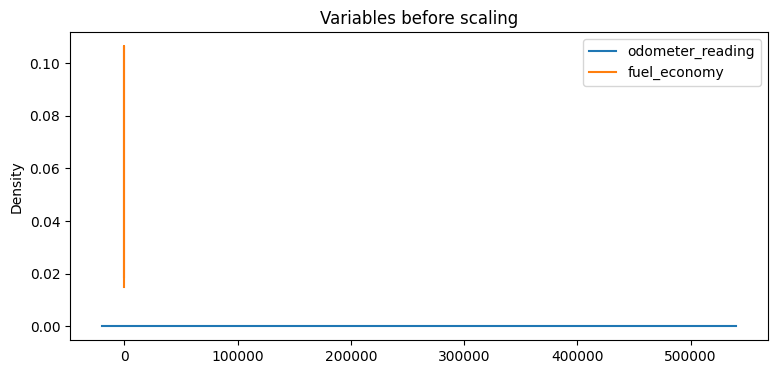

In [48]:
ax = df_cars.plot(kind='density', figsize=(9, 4))
ax.set_title('Variables before scaling')
plt.show()

<span style="color:#b91c1c">→ <strong>Interpretation:</strong> On the original axes, the large odometer scale separates the two density curves.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Implemented the TP&#x27;s manual min-max formula.</span>

In [49]:
def min_max_scaling(frame):
    result = frame.copy()
    for column in result.columns:
        span = result[column].max() - result[column].min()
        result[column] = (result[column] - result[column].min()) / span if span else 0.0
    return result

df_cars_normalized = min_max_scaling(df_cars)
display(df_cars_normalized)

,odometer_reading,fuel_economy
0,0.000000,0.142857
1,0.464286,0.214286
2,0.196429,0.828571
3,0.821429,1.000000
4,1.000000,0.000000


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Each column now ranges from 0 to 1 within this small example.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Plotted the variables after scaling.</span>

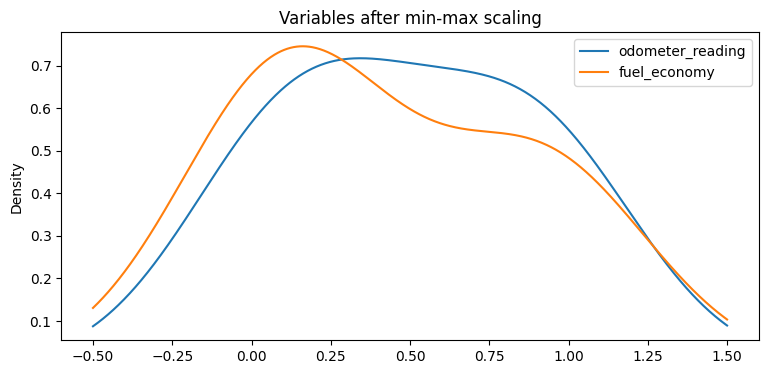

In [50]:
ax = df_cars_normalized.plot(kind='density', figsize=(9, 4))
ax.set_title('Variables after min-max scaling')
plt.show()

<span style="color:#b91c1c">→ <strong>Interpretation:</strong> After scaling, both density curves fit a common horizontal range, making their shapes easier to compare.</span>

#### Method 2:  Using MinMaxScaler

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Displayed the columns to scale.</span>

In [51]:
print('Columns to scale:', df_cars.columns.tolist())

Columns to scale: ['odometer_reading', 'fuel_economy']


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> These are the two numeric columns passed to the scaler.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Applied scikit-learn&#x27;s min-max scaler.</span>

In [52]:
minmax_scaler = MinMaxScaler(feature_range=(0, 1))
df_cars_normalized2 = pd.DataFrame(
    minmax_scaler.fit_transform(df_cars), columns=df_cars.columns, index=df_cars.index,
)
display(df_cars_normalized2)

,odometer_reading,fuel_economy
0,0.000000,0.142857
1,0.464286,0.214286
2,0.196429,0.828571
3,0.821429,1.000000
4,1.000000,0.000000


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> <code>MinMaxScaler</code> produces the same 0-to-1 values as the manual formula.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Compared both min-max calculations.</span>

In [53]:
print('Manual and sklearn results match:',
      np.allclose(df_cars_normalized, df_cars_normalized2))
display(df_cars_normalized2)

Manual and sklearn results match: True


,odometer_reading,fuel_economy
0,0.000000,0.142857
1,0.464286,0.214286
2,0.196429,0.828571
3,0.821429,1.000000
4,1.000000,0.000000


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The equality check confirms the manual and scikit-learn calculations agree to floating-point tolerance.</span>

#####  <font color='purple' > When Should You Use Normalization and Standardization:
                                                                                       
Normalization is a good technique to use when you do not know the distribution of your data or when you know the distribution is not Gaussian (a bell curve). Normalization is useful when your data has varying scales and the algorithm you are using does not make assumptions about the distribution of your data, such as k-nearest neighbors and artificial neural networks.

Standardization assumes that your data has a Gaussian (bell curve) distribution. This does not strictly have to be true, but the technique is more effective if your attribute distribution is Gaussian. Standardization is useful when your data has varying scales and the algorithm you are using does make assumptions about your data having a Gaussian distribution, such as linear regression, logistic regression, and linear discriminant analysis.

<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Standardization does not require a Gaussian distribution.</span>

<font color='blue' ><h3>
IV.4.  Dimensionality reduction </p><h3>


The dimensionality of a dataset is defined as the number of input variables or characteristics.


Dimensionality reduction techniques are those that lower the number of variables in a dataset.


For data visualization, high-dimensionality statistics and dimensionality reduction techniques are frequently used.
Nonetheless, in applied machine learning, similar strategies can be utilized to reduce a classification or regression dataset in order to better train a predictive model.

## PCA (Principal component Anlysis):
Principal component Anlysis is a dimensionality reduction technique used to reduce the number of predictor variables in a dataset.


PCA is a sort of unsupervised feature extraction in which original variables are integrated and reduced to their most important and descriptive components.



### Method(1): Manual Computation

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Prepared the manual PCA calculation.</span>

In [54]:
print('Manual PCA will use NumPy eigen-decomposition of the covariance matrix.')

Manual PCA will use NumPy eigen-decomposition of the covariance matrix.


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The manual route will expose each PCA calculation before comparing it with scikit-learn.</span>

The required work is to reduce the dimension of the stat2 dataset using PCA in two ways:
1. From scratch using manual computation
2. Computing using "pca" command

## DataSet: stat2

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Imputed five continuous Horse Colic features.</span>

In [55]:
# Use five continuous measurements, excluding outcome and coded categories.
pca_columns = ['rectal_temp', 'pulse', 'respiratory_rate',
               'packed_cell_volume', 'total_protein']
pca_raw = stat2[pca_columns].apply(pd.to_numeric, errors='coerce')
pca_imputed = pca_raw.fillna(pca_raw.median())
print('Missing values before / after:', int(pca_raw.isna().sum().sum()),
      '/', int(pca_imputed.isna().sum().sum()))
display(pca_imputed.head())

Missing values before / after: 204 / 0


,rectal_temp,pulse,respiratory_rate,packed_cell_volume,total_protein
0,38.5,66.0,28.0,45.0,8.4
1,39.2,88.0,20.0,50.0,85.0
2,38.3,40.0,24.0,33.0,6.7
3,39.1,164.0,84.0,48.0,7.2
4,37.3,104.0,35.0,74.0,7.4


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Median imputation removes missing cells from five continuous measurements before PCA.</span>

### Step(1): Data centering and reduction

The purpose of this step is to standardize the range of initial continuous variables so that each contributes equally to the analysis.
Mathematically, this can be done by subtracting the mean and dividing by the standard deviation for each value of each variable.
Once standardization is complete, all variables will be transformed to the same scale.

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Standardized those five features.</span>

In [56]:
# Standardize so variables measured in different units contribute comparably.
pca_scaler = StandardScaler()
Z = pca_scaler.fit_transform(pca_imputed)
display(pd.DataFrame(Z, columns=pca_imputed.columns).head())

,rectal_temp,pulse,respiratory_rate,packed_cell_volume,total_protein
0,0.496498,-0.194771,-0.087726,-0.119170,-0.533355
1,1.565603,0.604982,-0.588538,0.385530,2.380057
2,0.191039,-1.139933,-0.338132,-1.330449,-0.598013
3,1.412873,3.367763,3.417962,0.183650,-0.578996
4,-1.336253,1.186620,0.350485,2.808088,-0.571389


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Standardized measurements have comparable scales, so large units cannot dominate solely by magnitude.</span>

### Step(2): COMPUTATION OF THE COVARANCE MATRIX

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Computed their covariance matrix.</span>

In [57]:
covariance = np.cov(Z, rowvar=False)
display(pd.DataFrame(covariance, index=pca_imputed.columns,
                     columns=pca_imputed.columns).round(3))

,rectal_temp,pulse,respiratory_rate,packed_cell_volume,total_protein
rectal_temp,1.003,0.197,0.231,0.058,-0.050
pulse,0.197,1.003,0.435,0.371,-0.083
respiratory_rate,0.231,0.435,1.003,0.067,-0.087
packed_cell_volume,0.058,0.371,0.067,1.003,-0.053
total_protein,-0.050,-0.083,-0.087,-0.053,1.003


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The diagonal shows standardized variances; off-diagonal entries show how measurements vary together.</span>

#### Step(3): Compute the eigenvectors and eigenvalues of the covariance matrix to identify the principle components.

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Computed and ordered eigenvalues and eigenvectors.</span>

In [58]:
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
order = np.argsort(eigenvalues)[::-1]
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
manual_variance = eigenvalues / eigenvalues.sum()
display(pd.DataFrame({'eigenvalue': eigenvalues,
                      'variance_ratio': manual_variance},
                     index=[f'PC{i}' for i in range(1, len(eigenvalues) + 1)]).round(4))

,eigenvalue,variance_ratio
PC1,1.7537,0.3496
PC2,1.0157,0.2025
PC3,0.9767,0.1947
PC4,0.8071,0.1609
PC5,0.4636,0.0924


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Components are ordered by decreasing eigenvalue; variance ratios sum to one across all five components.</span>

### Step(4): Projection of the initial data on the new axes (the principal components)

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Projected onto the first two components.</span>

In [59]:
manual_projection = Z @ eigenvectors[:, :2]
display(pd.DataFrame(manual_projection, columns=['PC1', 'PC2']).head())

,PC1,PC2
0,-0.066600,-0.446325
1,-0.360752,0.149367
2,1.238226,-1.274286
3,-4.618527,-1.237492
4,-1.651364,2.779938


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The two coordinates are each horse&#x27;s projection onto the first two principal axes.</span>

## Method 2: Computation using "PCA"

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Started the scikit-learn PCA comparison.</span>

In [60]:
print('Using sklearn PCA on the same standardized matrix Z.')

Using sklearn PCA on the same standardized matrix Z.


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The library calculation below uses exactly the standardized matrix from the manual route.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Fitted a two-component PCA model.</span>

In [61]:
pca = PCA(n_components=2)
sklearn_projection = pca.fit_transform(Z)
print('Two-component projection:', sklearn_projection.shape)

Two-component projection: (299, 2)


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The projection has one row per horse and two principal-component coordinates.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Displayed component directions and variance.</span>

In [62]:
display(pd.DataFrame(pca.components_, columns=pca_imputed.columns,
                     index=['PC1', 'PC2']).round(3))
print('Explained variance ratio:', np.round(pca.explained_variance_ratio_, 4))

,rectal_temp,pulse,respiratory_rate,packed_cell_volume,total_protein
PC1,0.371,0.623,0.532,0.398,-0.184
PC2,-0.535,0.194,-0.344,0.730,0.162


Explained variance ratio: [0.3496 0.2025]


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Loadings describe each component&#x27;s direction; explained-variance ratios show how much variation each retains.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Compared the manual and library projections.</span>

In [63]:
display(pd.DataFrame(sklearn_projection, columns=['PC1', 'PC2']).head())
print('Manual and sklearn absolute score magnitudes agree:',
      np.allclose(np.abs(manual_projection), np.abs(sklearn_projection)))

,PC1,PC2
0,0.066600,-0.446325
1,0.360752,0.149367
2,-1.238226,-1.274286
3,4.618527,-1.237492
4,1.651364,2.779938


Manual and sklearn absolute score magnitudes agree: True


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Eigenvector signs can flip without changing PCA, so the comparison uses absolute score magnitudes.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Plotted explained variance by component.</span>

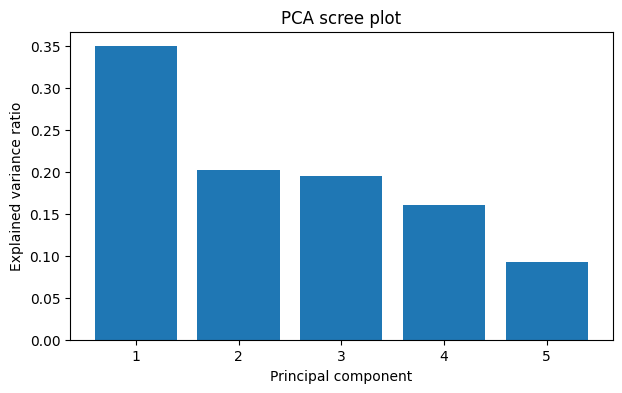

In [64]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(manual_variance) + 1), manual_variance)
ax.set(xlabel='Principal component', ylabel='Explained variance ratio',
       title='PCA scree plot', xticks=range(1, len(manual_variance) + 1))
plt.show()

<span style="color:#b91c1c">→ <strong>Interpretation:</strong> The bars show the share of total standardized variance explained by each component.</span>

<span style="color:#1d4ed8">→ <strong>Code update:</strong> Fitted PCA with all components.</span>

In [65]:
# Repeat with all components to show the complete PCA summary.
pca_full = PCA().fit(Z)
display(pd.DataFrame({'explained_variance_ratio': pca_full.explained_variance_ratio_,
                      'cumulative_ratio': np.cumsum(pca_full.explained_variance_ratio_)},
                     index=[f'PC{i}' for i in range(1, Z.shape[1] + 1)]).round(4))
print('All-component projection shape:', pca_full.transform(Z).shape)

,explained_variance_ratio,cumulative_ratio
PC1,0.3496,0.3496
PC2,0.2025,0.5520
PC3,0.1947,0.7467
PC4,0.1609,0.9076
PC5,0.0924,1.0000


All-component projection shape: (299, 5)


<span style="color:#b91c1c">→ <strong>Interpretation:</strong> Cumulative variance shows how many components are needed to retain a chosen share of variation.</span>